In [3]:
# 04 — Error Analysis (Baseline)

# This notebook analyzes baseline model errors for multi-label ICD coding:
# - Which codes perform best/worst and why
# - Impact of label frequency (imbalance)
# - Impact of note length
# - Qualitative examples of false positives and false negatives


In [5]:
# 1. imports + load data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 300)

df = pd.read_parquet("final_modeling_dataset.parquet")
df.head()

print("Rows:", len(df))
print("Unique admissions (hadm_id):", df["hadm_id"].nunique())
print("Avg codes per admission:", df["icd_code"].apply(len).mean())
print("Avg note length (chars):", df["text"].str.len().mean())


Rows: 115103
Unique admissions (hadm_id): 115103
Avg codes per admission: 5.369356141890307
Avg note length (chars): 11724.312650408765


In [7]:
# 2. train/test split

X = df["text"]
y = df["icd_code"]

X_train, X_test, y_train, y_test, hadm_train, hadm_test = train_test_split(
    X, y, df["hadm_id"],
    test_size=0.2,
    random_state=42
)

mlb = MultiLabelBinarizer()
Y_train = mlb.fit_transform(y_train)
Y_test = mlb.transform(y_test)

label_names = mlb.classes_
print("Num labels:", len(label_names))


Num labels: 50


In [9]:
# 3. fit the baseline

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=5,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

clf = OneVsRestClassifier(
    LogisticRegression(max_iter=2000, solver="liblinear")
)

clf.fit(X_train_tfidf, Y_train)

Y_pred = clf.predict(X_test_tfidf)
Y_score = clf.decision_function(X_test_tfidf)


micro = f1_score(Y_test, Y_pred, average="micro")
macro = f1_score(Y_test, Y_pred, average="macro")
print(f"Baseline Micro-F1: {micro:.4f}")
print(f"Baseline Macro-F1: {macro:.4f}")


Baseline Micro-F1: 0.5303
Baseline Macro-F1: 0.4179


In [10]:
# 4. per label performance table (best/worst codes)

rows = []
for j, code in enumerate(label_names):
    y_true_j = Y_test[:, j]
    y_pred_j = Y_pred[:, j]
    support = int(y_true_j.sum())
    if support == 0:
        continue

    p = precision_score(y_true_j, y_pred_j, zero_division=0)
    r = recall_score(y_true_j, y_pred_j, zero_division=0)
    f1 = f1_score(y_true_j, y_pred_j, zero_division=0)

    rows.append({"icd_code": code, "support": support, "precision": p, "recall": r, "f1": f1})

perf = pd.DataFrame(rows).sort_values(["f1", "support"], ascending=[False, False])
perf.head(10)
perf.tail(10)


,icd_code,support,precision,recall,f1
6,E669,2439,0.581236,0.104141,0.176634
34,N189,1719,0.489362,0.107039,0.175656
2,D696,1316,0.476190,0.075988,0.131062
46,Z8673,1572,0.539535,0.073791,0.129827
30,K5900,1399,0.527778,0.067906,0.120329
39,Y929,2368,0.439024,0.038007,0.069957
37,Y92230,1139,0.481481,0.034241,0.063934
1,D649,2513,0.474359,0.029447,0.055451
38,Y92239,1233,0.307692,0.003244,0.006421
40,Z23,1107,0.000000,0.000000,0.000000


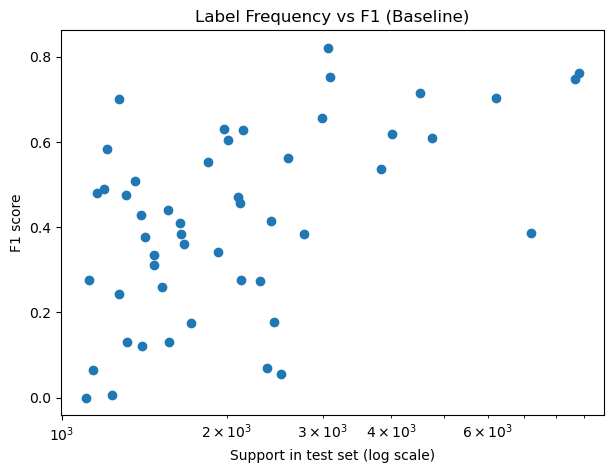

In [18]:
# 5. frequency vs. f1

plt.figure(figsize=(7,5))
plt.scatter(perf["support"], perf["f1"])
plt.xscale("log")
plt.xlabel("Support in test set (log scale)")
plt.ylabel("F1 score")
plt.title("Label Frequency vs F1 (Baseline)")
plt.show()


In [20]:
# 6. note length vs performance (do longer notes hurt?)

test_df = pd.DataFrame({
    "hadm_id": hadm_test.values,
    "text": X_test.values,
    "true_codes": y_test.values
})

test_df["note_len"] = test_df["text"].str.len()
test_df["num_true_codes"] = test_df["true_codes"].apply(len)
test_df.head()


,hadm_id,text,true_codes,note_len,num_true_codes
0,26310228,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: M\n \nService: MEDICINE\n \nAllergies: \nAmoxicillin\n \nAttending: ___.\n \nChief Complaint:\ninability to care for self\n \nMajor Surgical or Invas...,"[G8929, I2510, Z955, I10, J449, I252, F17210, E785]",11087,8
1,22854772,"\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: M\n \nService: MEDICINE\n \nAllergies: \nPenicillins / codeine\n \nAttending: ___.\n \nChief Complaint:\ncoronary angiogram/b/l carotid angiogram, exe...","[F17210, I252, M109, Z951]",12574,4
2,28799705,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: M\n \nService: MEDICINE\n \nAllergies: \nNo Known Allergies / Adverse Drug Reactions\n \nAttending: ___.\n \nChief Complaint:\nsyncope\n \nMajor Surgic...,"[I4891, E039, N400, Z8673, K219, K5900]",12826,6
3,29282809,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: M\n \nService: MEDICINE\n \nAllergies: \nNo Known Allergies / Adverse Drug Reactions\n \nAttending: ___.\n \nChief Complaint:\nPTBD tube replace...,"[K219, G4733]",4747,2
4,22777958,\nName: ___ Unit No: ___\n \nAdmission Date: ___ Discharge Date: ___\n \nDate of Birth: ___ Sex: F\n \nService: SURGERY\n \nAllergies: \nBactrim\n \nAttending: ___.\n \nChief Complaint:\nabdominal pain \n \nMajor Surgical or Invasive Procedure:\...,"[N390, I10, E785, K219]",5937,4


In [22]:
# Compute “example-level” micro F1 approximation (Jaccard as an intuitive proxy):

pred_lists = []
for i in range(Y_pred.shape[0]):
    pred_lists.append(list(label_names[np.where(Y_pred[i] == 1)[0]]))

test_df["pred_codes"] = pred_lists

def jaccard(a, b):
    a, b = set(a), set(b)
    if len(a | b) == 0:
        return 1.0
    return len(a & b) / len(a | b)

test_df["jaccard"] = test_df.apply(lambda r: jaccard(r["true_codes"], r["pred_codes"]), axis=1)
test_df["jaccard"].describe()


count    23021.000000
mean         0.349250
std          0.263471
min          0.000000
25%          0.142857
50%          0.333333
75%          0.500000
max          1.000000
Name: jaccard, dtype: float64

/var/folders/l3/ckv94d4x6jb2k203k51g9cl00000gn/T/ipykernel_82724/2515145969.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  len_summary = test_df.groupby("len_bin")["jaccard"].mean().reset_index()


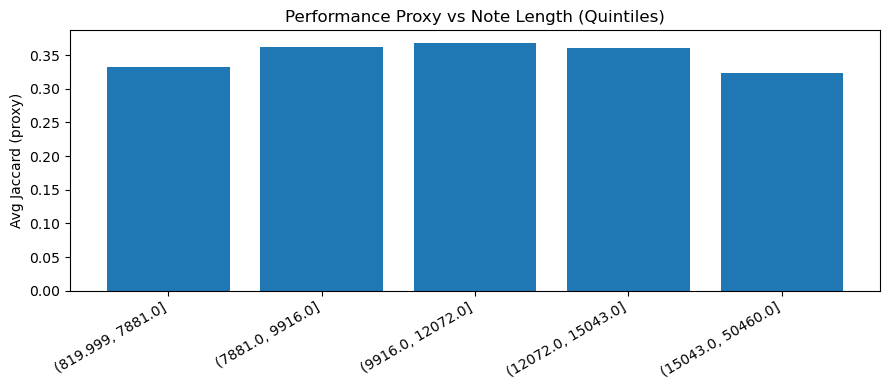

In [24]:
# Bin by length and plot:

test_df["len_bin"] = pd.qcut(test_df["note_len"], q=5, duplicates="drop")

len_summary = test_df.groupby("len_bin")["jaccard"].mean().reset_index()
len_summary


plt.figure(figsize=(9,4))
plt.bar(len_summary["len_bin"].astype(str), len_summary["jaccard"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Avg Jaccard (proxy)")
plt.title("Performance Proxy vs Note Length (Quintiles)")
plt.tight_layout()
plt.show()


In [26]:
# 7. Assistive coding view

def precision_recall_at_k(y_true_bin, y_score, k=5):
    precisions, recalls = [], []
    for i in range(y_true_bin.shape[0]):
        true_idx = set(np.where(y_true_bin[i] == 1)[0])
        if not true_idx:
            continue
        topk_idx = set(np.argsort(y_score[i])[-k:])
        precisions.append(len(true_idx & topk_idx) / k)
        recalls.append(len(true_idx & topk_idx) / len(true_idx))
    return float(np.mean(precisions)), float(np.mean(recalls))

for k in [3, 5, 10]:
    p, r = precision_recall_at_k(Y_test, Y_score, k=k)
    print(f"P@{k}: {p:.4f} | R@{k}: {r:.4f}")


P@3: 0.6663 | R@3: 0.4600
P@5: 0.5695 | R@5: 0.6123
P@10: 0.4079 | R@10: 0.8089


In [28]:
# 8. Qualitative Error examples

def topk_codes_for_row(i, k=10):
    idx = np.argsort(Y_score[i])[-k:][::-1]
    return list(label_names[idx])

def true_codes_for_row(i):
    return list(label_names[np.where(Y_test[i] == 1)[0]])


In [ ]:
# Pick a code to inspect (choose a “hard” one from perf.tail())
# hard_code = perf.sort_values("f1").iloc[0]["icd_code"]
# hard_code


# Find false negatives (missed true code):

# code_idx = np.where(label_names == hard_code)[0][0]
# fn_rows = np.where((Y_test[:, code_idx] == 1) & (Y_pred[:, code_idx] == 0))[0]
# fp_rows = np.where((Y_test[:, code_idx] == 0) & (Y_pred[:, code_idx] == 1))[0]

# len(fn_rows), len(fp_rows)


# Show a few FN examples:

# for i in fn_rows[:3]:
#     print("="*120)
#     print("HADM_ID:", test_df.iloc[i]["hadm_id"])
#     print("TRUE codes:", true_codes_for_row(i))
#     print("TOP-10 predicted:", topk_codes_for_row(i, k=10))
#     print("\nNOTE (first 1200 chars):\n", test_df.iloc[i]["text"][:1200])


# Show a few FP examples:

# for i in fp_rows[:3]:
#     print("="*120)
#     print("HADM_ID:", test_df.iloc[i]["hadm_id"])
#     print("TRUE codes:", true_codes_for_row(i))
#     print("TOP-10 predicted:", topk_codes_for_row(i, k=10))
#     print("\nNOTE (first 1200 chars):\n", test_df.iloc[i]["text"][:1200])

In [ ]:
# 9. Findings for paper

- **Label imbalance:** F1 tends to increase with label frequency (support), showing the long-tail challenge.
- **Long notes:** Performance proxy may degrade with longer notes due to more conditions and truncation-like effects even in TF-IDF.
- **Common FN patterns:** negation (“no evidence of …”), implicit diagnoses, abbreviations, or evidence spread across note sections.
- **Common FP patterns:** historical conditions, ruled-out diagnoses, or terms used in a different context.
- **Assistive perspective:** Precision@K / Recall@K helps justify use as a coder-assist tool.
